# library for data augmentation
why this instead of torchvision(acc to 5 yrs old vid)
- faster in all benchmark
- supports for more task
- and that guy don't remember the 3rd point.

## Plotting images

In [12]:
import random
import cv2
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import numpy as np
import albumentations as A


def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(image)
    plt.show()


def plot_examples(images, bboxes=None):
    fig = plt.figure(figsize=(15, 15))
    columns = 6
    rows = 6

    for i in range(1, len(images)):
        if bboxes is not None:
            img = visualize_bbox(images[i - 1], bboxes[i - 1], class_name="Elon")
        else:
            img = images[i - 1]
        fig.add_subplot(rows, columns, i)
        plt.imshow(img)
    plt.show()


# From https://albumentations.ai/docs/examples/example_bboxes/
def visualize_bbox(img, bbox, class_name, color=(255, 0, 0), thickness=5):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, x_max, y_max = map(int, bbox)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, thickness)
    return img

## Albu.. for classification

In [2]:
import cv2
import albumentations as A
import numpy as np
# from utils import plot_examples
from PIL import Image

In [3]:
image = Image.open('data/elon.jpeg')

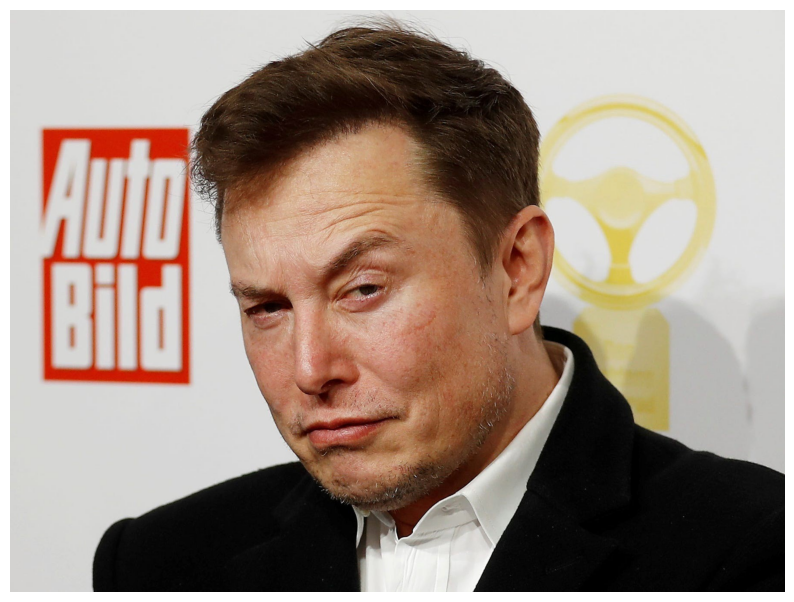

In [13]:
visualize(image)

In [4]:
transform = A.Compose(
    [
        A.Resize(width = 1920, height=1080),
        A.RandomCrop(width=1080, height = 1070),
        A.Rotate(limit = 40, p = 0.9, border_mode=cv2.BORDER_CONSTANT),
        A.HorizontalFlip(p = 0.5),
        A.VerticalFlip(p=0.1),
        A.RGBShift(r_shift_limit = 25, g_shift_limit=43, b_shift_limit = 25, p = 0.9),
        A.OneOf([
            A.Blur(blur_limit = 3, p = 0.5),
            A.ColorJitter(p=0.5,)
        ], p=1.0)
    ]
)




In [15]:
type(transform)

albumentations.core.composition.Compose

In [8]:
images_list = []
len(images_list)

0

In [5]:
image = np.array(image)
image[0][0][2]

np.uint8(215)

In [22]:
for i in range(15):
    augmentations = transform(image = image)
    augmentated_img = augmentations['image']
    images_list.append(augmentated_img)
    # print(augmentated_img.shape)
    # break



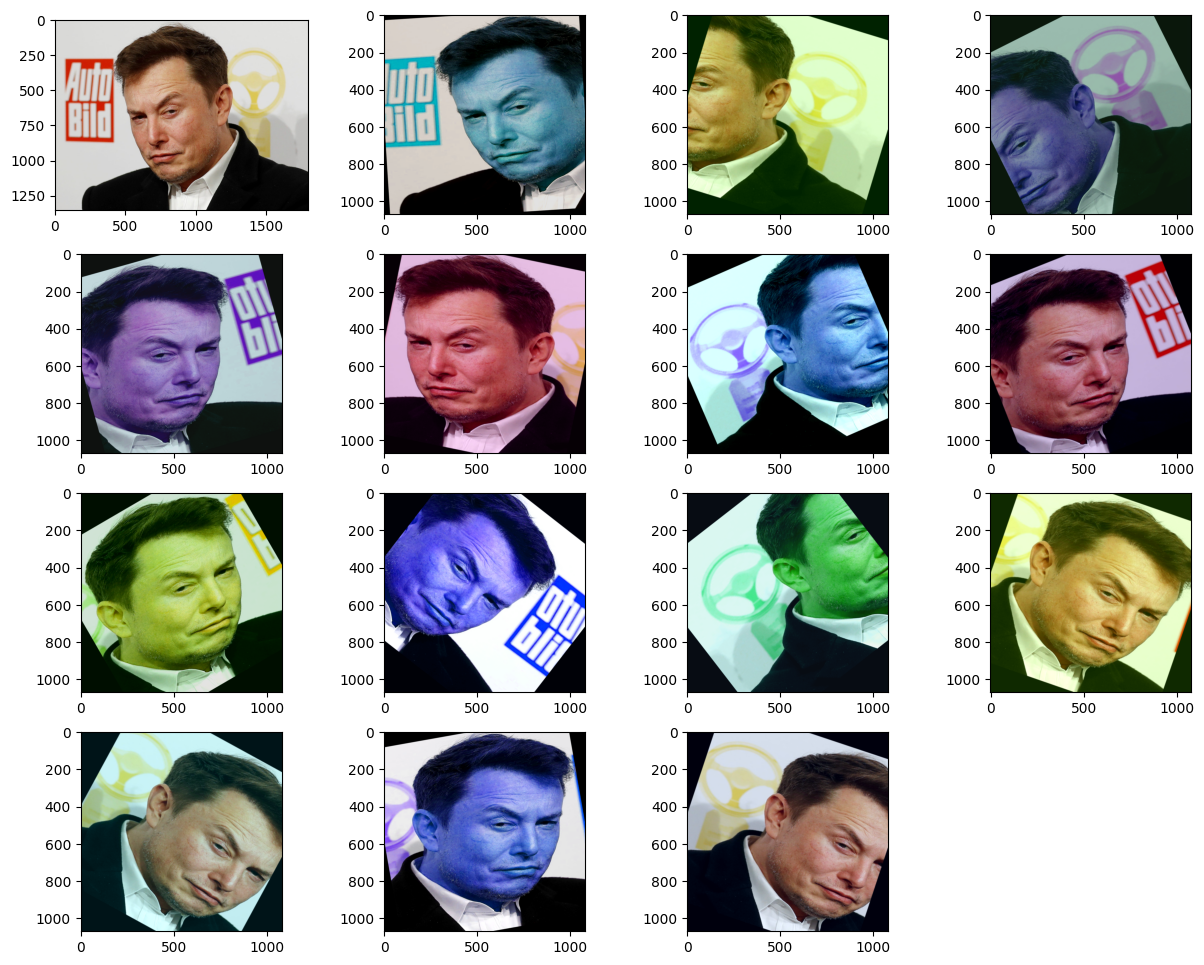

In [27]:
plot_examples(images_list)
# [plot_examples(x) for x in images_list]

## Albu... for segmentation

In [26]:
mask = Image.open('data/mask.jpeg')
mask = np.array(mask)
transform.is_check_shapes=False


In [19]:
for i in range(6):
    augmentations = transform(image = image, mask = mask)
    augmented_img = augmentations['image']
    augmented_mask = augmentations['mask']
    images_list.append(augmented_img)
    images_list.append(augmented_mask)
    # print(augmentated_img.shape)
    # break



In [20]:
mask.shape

(1350, 1790, 3)

In [21]:
image.shape

(1350, 1797, 3)

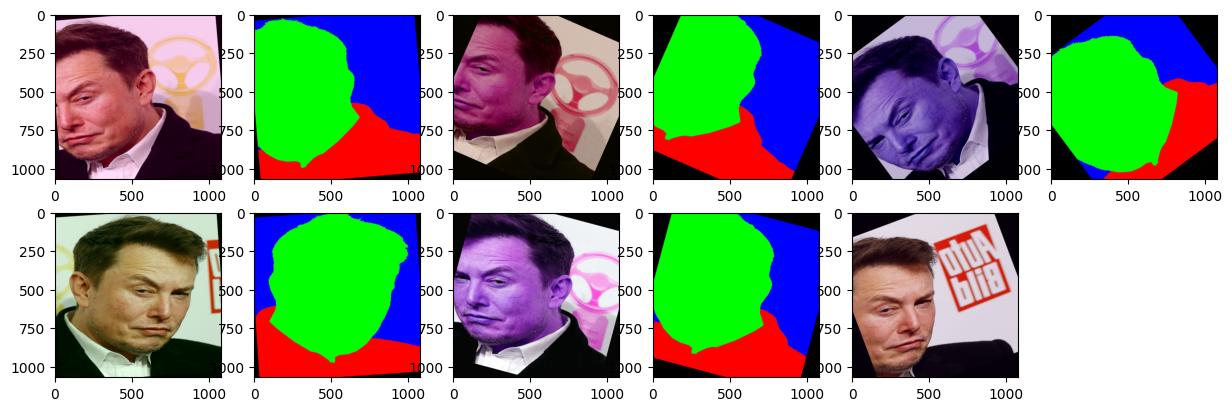

In [22]:
plot_examples(images_list)

In [27]:
mask2 = Image.open('data/second_mask.jpeg')
mask2 = np.array(mask2)

In [28]:
for i in range(6):
    augmentations = transform(image = image, masks = [mask, mask2])
    augmented_img = augmentations['image']
    augmented_mask = augmentations['masks']
    images_list.append(augmented_img)
    images_list.append(augmented_mask[0])
    images_list.append(augmented_mask[1])
    # print(augmentated_img.shape)
    # break



ValueError: all input arrays must have the same shape

In [29]:
mask2.shape

(750, 991, 3)

In [31]:
mask.shape

(1350, 1790, 3)

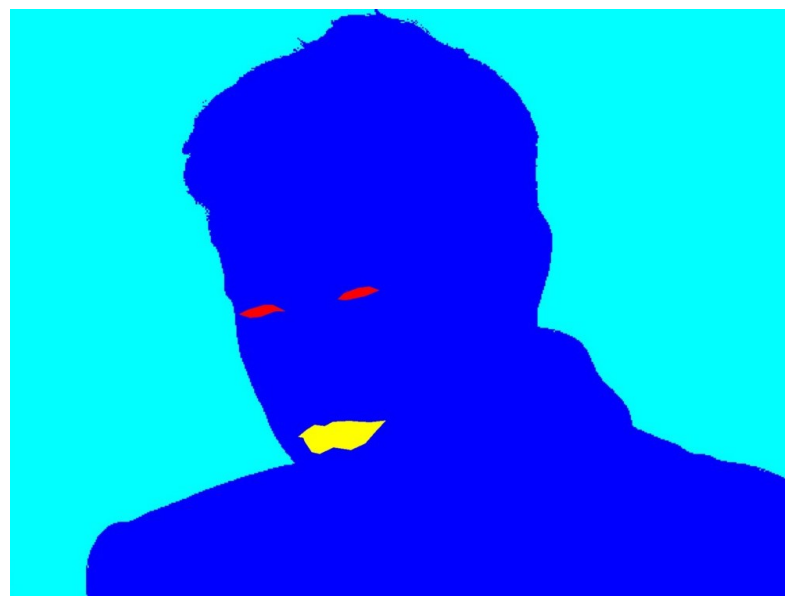

In [32]:
visualize(mask2)